# 📊 Análise de Performance de Vendas com Foco em Planejamento Estratégico

Este projeto tem como objetivo analisar dados de vendas para gerar indicadores de desempenho (KPIs), acompanhar metas e propor ações estratégicas baseadas em dados.

A análise simula o papel de um analista de planejamento estratégico, auxiliando na tomada de decisão e no monitoramento de resultados.

## 🧠 Contexto de Negócio

Empresas orientadas a dados utilizam indicadores de desempenho para monitorar resultados e tomar decisões estratégicas.

Neste cenário, a área de planejamento estratégico atua acompanhando metas, analisando resultados e propondo melhorias contínuas.

Este projeto simula esse contexto utilizando dados de vendas.

## ❗ Problema

A empresa possui dados de vendas, mas não tem clareza sobre:

- Quais produtos geram mais lucro
- Quais regiões performam melhor
- Se as metas estão sendo atingidas
- Onde estão as principais oportunidades de melhoria

Sem essas informações, a tomada de decisão se torna limitada.

## 🎯 Objetivo Estratégico (OKR)

**Objetivo:** Aumentar a receita e melhorar a performance de vendas

**Resultados-chave (Key Results):**
- Aumentar o faturamento em 15%
- Aumentar o ticket médio em 20%
- Reduzir devoluções em 10%
- Melhorar a margem de lucro

## 📁 Fonte de Dados

Os dados utilizados são provenientes de um dataset público de vendas (Retail/Superstore), contendo informações como:

- Data da venda
- Produto
- Categoria
- Região
- Receita
- Quantidade
- Lucro
- Descontos

Esses dados permitem análise completa de desempenho comercial.

## 🔍 Entendimento dos Dados

Nesta etapa, será feita a exploração inicial do dataset para compreender:

- Estrutura dos dados
- Tipos de variáveis
- Qualidade dos dados
- Possíveis inconsistências

Objetivo: preparar os dados para análise confiável.

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [133]:
tabela = pd.read_csv("train.csv")
tabela.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [134]:
tabela.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [135]:
tabela.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [136]:
tabela.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

## 🧹 Tratamento dos Dados

Nesta etapa, os dados serão preparados para análise:

- Tratamento de valores ausentes
- Padronização de categorias
- Criação de métricas auxiliares
- Ajustes estruturais

Objetivo: garantir consistência e qualidade dos dados.

In [137]:
tabela.columns = tabela.columns.str.strip().str.lower().str.replace(" ", "_")

In [138]:
tabela["order_date"] = pd.to_datetime(tabela["order_date"], dayfirst=True)
tabela["ship_date"] = pd.to_datetime(tabela["ship_date"], dayfirst=True)

In [139]:
tabela["order_date"] = pd.to_datetime(tabela["order_date"])
tabela["ship_date"] = pd.to_datetime(tabela["ship_date"])

In [140]:
tabela = tabela.drop(columns=["postal_code"])

In [141]:
tabela.duplicated().sum()

np.int64(0)

In [142]:
tabela["ano"] = tabela["order_date"].dt.year

In [143]:
tabela["mes"] = tabela["order_date"].dt.month

In [144]:
tabela["tempo_entrega"] = (tabela["ship_date"] - tabela["order_date"]).dt.days

In [145]:
ticket_medio = tabela.groupby("order_id")["sales"].sum().mean()

In [146]:
tabela["segment"].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [147]:
tabela["region"].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

In [148]:
tabela["category"].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

## 📊 Indicadores de Desempenho (KPIs)

Nesta etapa, serão definidos os principais indicadores para acompanhamento estratégico da performance de vendas.

Os KPIs permitem medir resultados, comparar desempenho entre áreas e apoiar a tomada de decisão baseada em dados.

### 💰 Receita Total

Cálculo do faturamento total da empresa no período analisado.

Este indicador permite avaliar o desempenho geral do negócio.

In [149]:
receita_total = tabela["sales"].sum()
receita_total

np.float64(2261536.7827)

### 🌍 Receita por Região

Análise da distribuição da receita entre as diferentes regiões.

Permite identificar quais regiões apresentam melhor desempenho e onde existem oportunidades de crescimento.

In [150]:
tabela.groupby("region")["sales"].sum().sort_values(ascending=False)

region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: sales, dtype: float64

### 💳 Ticket Médio

Cálculo do valor médio por pedido.

Este indicador é essencial para entender o comportamento de compra dos clientes e identificar oportunidades de aumento de receita.

In [151]:
ticket_medio = tabela.groupby("order_id")["sales"].sum().mean()
ticket_medio

np.float64(459.4751691791955)

### 📈 Receita ao Longo do Tempo

Análise da evolução da receita ao longo dos períodos.

Permite identificar crescimento, queda e possíveis padrões sazonais.

In [152]:
receita_tempo = tabela.groupby(["ano", "mes"])["sales"].sum()
receita_tempo

ano   mes
2015  1       14205.7070
      2        4519.8920
      3       55205.7970
      4       27906.8550
      5       23644.3030
      6       34322.9356
      7       33781.5430
      8       27117.5365
      9       81623.5268
      10      31453.3930
      11      77907.6607
      12      68167.0585
2016  1       18066.9576
      2       11951.4110
      3       32339.3184
      4       34154.4685
      5       29959.5305
      6       23599.3740
      7       28608.2590
      8       36818.3422
      9       63133.6060
      10      31011.7375
      11      75249.3995
      12      74543.6012
2017  1       18542.4910
      2       22978.8150
      3       51165.0590
      4       38679.7670
      5       56656.9080
      6       39724.4860
      7       38320.7830
      8       30542.2003
      9       69193.3909
      10      59583.0330
      11      79066.4958
      12      95739.1210
2018  1       43476.4740
      2       19920.9974
      3       58863.4128
      4       3

In [153]:
receita_categoria = tabela.groupby("category")["sales"].sum()
receita_categoria

category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: sales, dtype: float64

### 🏆 Produtos Mais Vendidos

Identificação dos produtos com maior geração de receita.

Permite orientar estratégias comerciais e de marketing.

In [154]:
tabela.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(10)

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64

### 🚚 Tempo Médio de Entrega

Análise da eficiência logística com base no tempo entre o pedido e a entrega.

Impacta diretamente a experiência do cliente.

In [155]:
tabela["tempo_entrega"].mean()

np.float64(3.9611224489795918)

## 📊 Análise Exploratória de Dados (EDA)

Nesta etapa, serão analisados padrões, tendências e relações nos dados de vendas.

O objetivo é identificar oportunidades, riscos e comportamentos relevantes que apoiem a tomada de decisão estratégica.

### 📈 Receita ao Longo do Tempo

Análise da evolução da receita ao longo dos períodos para identificar crescimento, queda e sazonalidade.

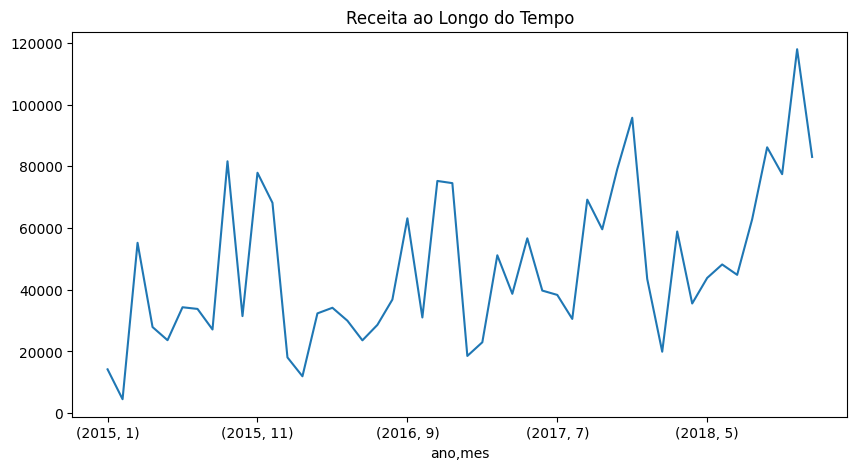

In [156]:
receita_tempo.plot(figsize=(10,5))
plt.title("Receita ao Longo do Tempo")
plt.show()

### 💡 Análise

Observa-se uma tendência de crescimento da receita ao longo dos anos, com destaque para o período após 2016, onde há uma aceleração significativa no faturamento.

Esse comportamento sugere melhorias nas estratégias comerciais ou expansão do mercado, indicando um momento favorável para consolidação e crescimento do negócio.

### 🌍 Receita por Região

Visualização da distribuição da receita entre regiões.

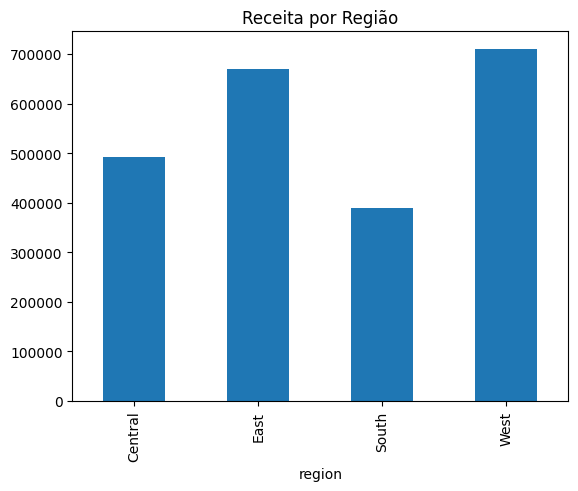

In [157]:
receita_regiao.plot(kind="bar")
plt.title("Receita por Região")
plt.show()

### 💡 Análise

A distribuição da receita evidencia uma concentração nas regiões West e East, que lideram o faturamento.

Por outro lado, a região South apresenta desempenho inferior, indicando possível oportunidade de crescimento e necessidade de revisão das estratégias comerciais nessa localidade.

### 🛍️ Receita por Categoria

Análise da contribuição de cada categoria de produtos para a receita total.

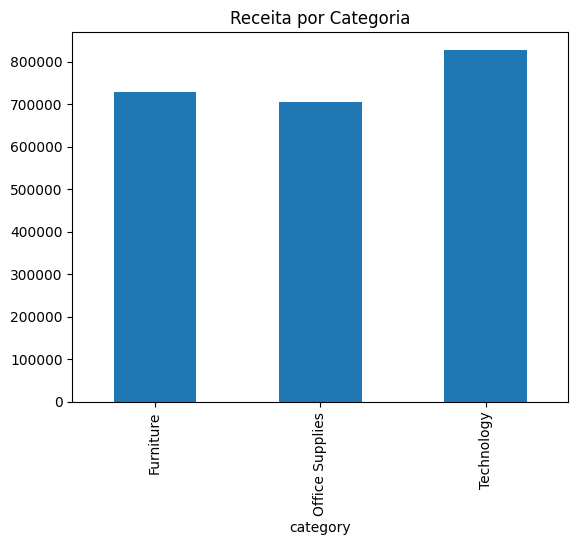

In [158]:
receita_categoria.plot(kind="bar")
plt.title("Receita por Categoria")
plt.show()

### 💡 Análise

A categoria Technology se destaca como principal geradora de receita, indicando maior valor percebido pelos clientes.

As demais categorias apresentam desempenho próximo, sugerindo potencial para estratégias de otimização e aumento de participação no faturamento total.

### 💳 Ticket Médio por Região

Análise do valor médio por pedido em cada região.

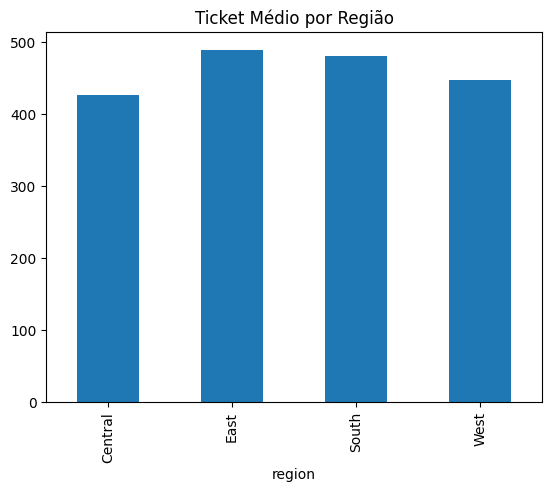

In [159]:
ticket_regiao.plot(kind="bar")
plt.title("Ticket Médio por Região")
plt.show()

### 💡 Análise

O ticket médio apresenta um valor moderado, indicando que os clientes realizam compras de valor intermediário.

Esse cenário abre espaço para estratégias de aumento de receita por pedido, como vendas combinadas (cross-sell) e ofertas de maior valor agregado (upsell).

### 🚚 Tempo de Entrega

Análise do tempo entre pedido e entrega.

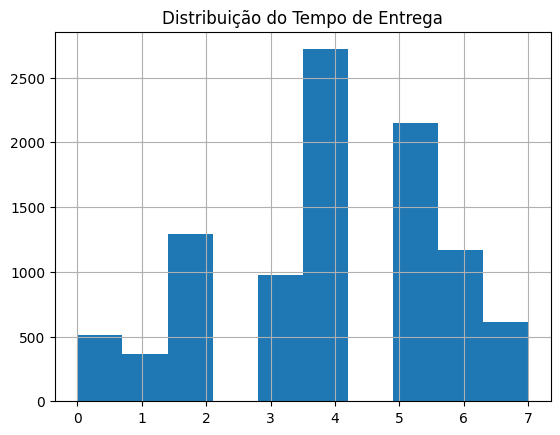

In [160]:
tabela["tempo_entrega"].hist()
plt.title("Distribuição do Tempo de Entrega")
plt.show()

### 💡 Análise

O tempo médio de entrega mostra-se eficiente, o que contribui positivamente para a experiência do cliente.

Manter esse padrão é fundamental para sustentar a satisfação e fidelização, sendo importante também monitorar possíveis variações ou atrasos.

## 🔎 Análises Cruzadas e Investigação Estratégica

Nesta etapa, são realizadas análises cruzadas entre variáveis para aprofundar o entendimento dos dados e identificar padrões mais complexos.

O objetivo é ir além da análise descritiva, buscando explicar possíveis causas para os resultados observados.

### 🌍🛍️ Receita por Região e Categoria

Análise da distribuição da receita considerando simultaneamente região e categoria de produtos.

Essa abordagem permite identificar quais categorias impulsionam o desempenho em cada região.

In [161]:
tabela.groupby(["region", "category"])["sales"].sum().unstack()

category,Furniture,Office Supplies,Technology
region,,,
Central,160317.4622,163590.243,168739.208
East,206461.3880,199940.811,263116.527
South,116531.4800,124424.771,148195.208
West,245348.2455,217466.509,247404.930


### 💡 Análise

A análise cruzada entre região e categoria permite identificar padrões mais detalhados de desempenho.

É possível observar se determinadas categorias têm maior relevância em regiões específicas, o que pode indicar diferenças no comportamento do consumidor ou estratégias comerciais distintas.

Essa visão ajuda a entender não apenas onde a empresa vende mais, mas também o que está sendo vendido em cada local.

### 💳🌍 Ticket Médio por Região

Análise do valor médio por pedido em cada região, permitindo avaliar o comportamento de consumo dos clientes.

In [162]:
ticket_regiao = tabela.groupby(["region", "order_id"])["sales"].sum().groupby("region").mean()
ticket_regiao

region
Central    426.165150
East       489.056776
South      480.433900
West       447.523431
Name: sales, dtype: float64

### 💡 Análise

O ticket médio por região permite avaliar se o desempenho está relacionado ao volume de vendas ou ao valor gasto por cliente.

Regiões com ticket médio mais alto podem indicar maior poder de compra ou maior valor agregado nos produtos vendidos.

Já regiões com ticket mais baixo podem representar oportunidade para estratégias de aumento de receita por cliente.

### 📈🛍️ Receita por Categoria ao Longo do Tempo

Análise da evolução das categorias ao longo do tempo para identificar tendências de crescimento ou queda.

In [163]:
tabela.groupby(["ano", "category"])["sales"].sum().unstack()

category,Furniture,Office Supplies,Technology
ano,,,
2015,156477.8811,149512.820,173865.507
2016,164053.8674,133124.407,162257.731
2017,195813.0400,182417.566,221961.944
2018,212313.7872,240367.541,269370.691


### 💡 Análise

A análise temporal por categoria permite identificar quais segmentos estão crescendo ou perdendo relevância ao longo do tempo.

Essa informação é essencial para decisões estratégicas, como priorização de investimentos e ajustes no portfólio de produtos.

## 🧠 Formulação de Hipóteses

Com base nas análises realizadas, foram levantadas hipóteses para explicar os padrões observados nos dados.

Essas hipóteses ajudam a direcionar investigações futuras e apoiar decisões estratégicas.

- A menor performance da região South pode estar associada a um ticket médio inferior em comparação com outras regiões.

- A concentração de receita na categoria Technology pode indicar maior valor percebido ou maior demanda por esses produtos.

- O crescimento observado a partir de 2017 pode estar relacionado a melhorias na estratégia comercial ou expansão da atuação da empresa.

- Diferenças de desempenho entre regiões podem estar associadas ao mix de produtos vendidos em cada localidade.

## 💡 Insights Estratégicos

- A receita está concentrada nas regiões West e East, indicando dependência dessas áreas.
- A região South apresenta baixo desempenho, sugerindo oportunidade de crescimento.
- A categoria Technology é a principal geradora de receita, sendo estratégica para o negócio.
- A empresa apresentou crescimento consistente após 2016.
- O tempo médio de entrega é eficiente (~4 dias).
- O ticket médio (~459) indica potencial para aumento de receita por pedido.

## 🛠️ Plano de Ação

- Expandir atuação comercial na região South
- Intensificar estratégias nas regiões de maior performance (West e East)
- Focar investimentos na categoria Technology
- Criar estratégias para aumento de ticket médio (upsell e cross-sell)
- Manter eficiência logística e monitorar possíveis atrasos
- Replicar estratégias que impulsionaram o crescimento após 2016

## 📖 Interpretação Estratégica dos Dados

A análise dos dados revela um cenário de crescimento consistente do negócio, impulsionado principalmente pelas regiões West e East e pela categoria Technology.

Apesar do bom desempenho geral, observa-se uma concentração de receita em determinadas regiões, o que pode representar um risco estratégico caso não haja diversificação.

A região South, por sua vez, apresenta desempenho inferior, indicando potencial oportunidade de expansão e necessidade de revisão das estratégias comerciais.

Além disso, o comportamento de consumo sugere espaço para aumento do ticket médio, o que pode ser explorado por meio de estratégias de vendas mais direcionadas.

De forma geral, os dados indicam um negócio com base sólida, mas com oportunidades claras de otimização e crescimento.

## ✅ Conclusão

A análise dos dados de vendas permitiu uma visão abrangente da performance do negócio, evidenciando padrões relevantes e oportunidades estratégicas.

A empresa apresentou um faturamento total superior a 2,26 milhões, com crescimento consistente ao longo dos anos, especialmente a partir de 2017, indicando evolução positiva das estratégias comerciais.

Observou-se uma concentração significativa da receita nas regiões West e East, o que demonstra forte desempenho nessas áreas, mas também evidencia uma dependência que pode representar risco estratégico. Em contrapartida, a região South apresentou menor participação, sugerindo potencial de expansão e necessidade de ações direcionadas.

No que se refere ao portfólio de produtos, a categoria Technology se destacou como principal geradora de receita, consolidando-se como um pilar estratégico do negócio. As demais categorias apresentam desempenho relevante, porém com oportunidades de otimização.

O ticket médio, em torno de 459 por pedido, indica um comportamento de consumo moderado, com espaço para crescimento por meio de estratégias de aumento de valor por cliente. Além disso, o tempo médio de entrega de aproximadamente 4 dias demonstra eficiência logística, contribuindo positivamente para a experiência do cliente.

De forma geral, os dados indicam um negócio em crescimento, com bases sólidas, mas que pode evoluir significativamente por meio de estratégias focadas em expansão regional, otimização do mix de produtos e aumento do ticket médio.

O uso de dados neste contexto mostrou-se fundamental para apoiar decisões mais assertivas e direcionar o planejamento estratégico da empresa.

In [164]:
tabela.to_csv("dados_tratados.csv", index=False)